ข้อมูลมาจาก: https://www.kaggle.com/datasets/orvile/satellite-telemetry-data-anomaly-prediction
โดยข้อมูลนั้นมาจากดาวเทียมทดลองของESAโดยที่ รหัสเซนเซอร์แต่ละตัวนั้นมีความหมายดังนี้ และเพื่อความเข้าใจง่ายได้เปลี่ยนรหัสเปนเซอร์เป็นคำที่เข้าใจง่าย

From: https://www.researchgate.net/publication/367091759_TOWARD_ON-BOARD_DETECTION_OF_ANOMALOUS_EVENTS_FROM_OPS-SAT_TELEMETRY_USING_DEEP_LEARNING It stated that “ For the magnetometer signals, they came from the profile 
called “06_iADCS_cADCS_magnetometer” which is built of the following parameters: I_B_FB_MM_0 (CADC0872), 
I_B_FB_MM_1 (CADC0873), I_B_FB_MM_2 CADC0874 “ which IADCS_cADCS stand for integrated attitude determination and control  | Theta mean angle of incident in the Photo Detector

FRom: https://www.researchgate.net/publication/393695267_OPS-SAT-1's_Final_Orbits_and_Reentry_Analysis_Amid_Mission_Extension_Attempts
cADCS stand for “ OPS-SAT-1 featured two ADCS systems: coarse and ﬁne.
The coarse Attitude Determination and Control Subsystem
(cADCS)” and “ The cADCS was composed of three
magnetorquers, a magnetometer, a gyroscope, six coarse sun
sensors, and a ﬁne sun senso”

Assuming “Gemini” standard 3D array in 0 index array it’s [x, y, z] being [0, 1, 2]

From: https://www.eoportal.org/satellite-missions/ops-sat#fine-adcs-attitude-determination-and-control-subsystem
The ADCS sensor inputs included sun sensors located on the exterior solar panels and a 3-axis Honeywell MC5843 magnetometer Eoportal is information platform operate by ESA

Magnetometer sensor
CADC0872 (I_B_FB_MM_0) is now MAG_X
CADC0873 (I_B_FB_MM_1) is now MAG_Y
CADC0874 (I_B_FB_MM_2) is now MAG_Z

Photo detector sensor 	
CADC0884 is now PD_1
CADC0886 is now PD_2
CADC0888 is now PD_3
CADC0890 is now PD_4
CADC0892 is now PD_5
CADC0894 is now PD_6

In [1]:
import pandas as pd

# 1. โหลดข้อมูลต้นฉบับ
df = pd.read_csv('segments.csv')

# 2. แยกข้อมูลเซนเซอร์ออกมาและตั้งชื่อคอลัมน์ตามชื่อเซนเซอร์
# ใช้ 'timestamp' เป็นตัวเชื่อมข้อมูลหลัก 
# 'columns' คือสิ่งที่จะกลายเป็น Header (เช่น CADC0872)
# 'values' คือตัวเลขที่จะถูกนำมาใส่ใต้ Header นั้นๆ
sensors_df = df.pivot(index='timestamp', columns='channel', values='value')

# ลบชื่อกำกับแกนคำว่า 'channel' ออกเพื่อให้ส่วนหัวตารางดูสะอาด
sensors_df.columns.name = None

# 3. ดึงกลุ่มป้ายกำกับ (Labels & Metadata)
# กรุ๊ปตามเวลาแล้วเลือกเอาเฉพาะข้อมูลสถานะที่ซ้ำกันมา 1 แถวต่อ 1 ช่วงเวลา
meta_df = df.groupby('timestamp')[['label', 'anomaly', 'segment', 'train']].first()

# 4. นำข้อมูลมารวมกัน (Merge)
# นำคอลัมน์ที่เป็นตัวเลขเซนเซอร์ (sensors_df) มาต่อเข้ากับคอลัมน์ป้ายกำกับ (meta_df) 
df_wide = sensors_df.join(meta_df).reset_index()

# เรียงลำดับตามเวลาให้ถูกต้อง
df_wide = df_wide.sort_values(by='timestamp').reset_index(drop=True)

# 5. บันทึกผลลัพธ์ลงไฟล์ใหม่
# ข้อมูลใดที่เซนเซอร์ไม่ได้ส่งมาในเวลานั้นๆ จะถูกปล่อยเป็นช่องว่าง (blank) ทันที
df_wide.to_csv('Data_sorted.csv', index=False)

print("แปลงไฟล์สำเร็จ! ชื่อเซนเซอร์ถูกตั้งเป็น Header และไม่ทำให้ข้อมูลสูญหายแล้วครับ!")

แปลงไฟล์สำเร็จ! ชื่อเซนเซอร์ถูกตั้งเป็น Header และไม่ทำให้ข้อมูลสูญหายแล้วครับ!


In [7]:
import pandas as pd

# 1. โหลดข้อมูลจากไฟล์ที่เรียงลำดับแล้ว
df = pd.read_csv('Data_sorted.csv')

# 2. สร้างดิกชันนารี (Dictionary) เพื่อจับคู่ชื่อคอลัมน์เก่ากับชื่อใหม่
rename_map = {
    'CADC0872': 'MAG_X',
    'CADC0873': 'MAG_Y',
    'CADC0874': 'MAG_Z',
    'CADC0884': 'PD_1',
    'CADC0886': 'PD_2',
    'CADC0888': 'PD_3',
    'CADC0890': 'PD_4',
    'CADC0892': 'PD_5',
    'CADC0894': 'PD_6'
}

# 3. สั่งเปลี่ยนชื่อคอลัมน์ตามที่จับคู่ไว้
df = df.rename(columns=rename_map)

# 4. บันทึกผลลัพธ์ลงในไฟล์ CSV ใหม่
df.to_csv('Data_renamed.csv', index=False)

print("เปลี่ยนชื่อคอลัมน์สำเร็จ! ไฟล์ใหม่ชื่อ 'Data_renamed.csv'")

เปลี่ยนชื่อคอลัมน์สำเร็จ! ไฟล์ใหม่ชื่อ 'Data_renamed.csv'


In [9]:
import pandas as pd

# 1. โหลดข้อมูล (ที่มีทั้ง MAG และ PD)
df = pd.read_csv('Data_renamed.csv')

# 2. ลบแค่คอลัมน์ 'label' ทิ้งอย่างเดียว
if 'label' in df.columns:
    df_cleaned = df.drop(columns=['label'])
else:
    df_cleaned = df

# 3. จัดเรียงข้อมูลตาม segment และ timestamp 
df_cleaned = df_cleaned.sort_values(by=['segment', 'timestamp']).reset_index(drop=True)

# 4. บันทึกไฟล์
output_file = 'Data_renamed.csv'
df_cleaned.to_csv(output_file, index=False)

print("✅ ลบคอลัมน์ 'label' สำเร็จ")
print("✅ จัดเรียงข้อมูลตาม Segment และลำดับเวลาเรียบร้อย")
print(f"✅ คอลัมน์ที่เหลือ: {df_cleaned.columns.tolist()}")

✅ ลบคอลัมน์ 'label' สำเร็จ
✅ จัดเรียงข้อมูลตาม Segment และลำดับเวลาเรียบร้อย
✅ คอลัมน์ที่เหลือ: ['timestamp', 'MAG_X', 'MAG_Y', 'MAG_Z', 'PD_1', 'PD_2', 'PD_3', 'PD_4', 'PD_5', 'PD_6', 'anomaly', 'segment', 'train']


In [1]:
import pandas as pd
import numpy as np

# 1. โหลดข้อมูล (ที่ลบ label และเรียง segment มาแล้ว)
df = pd.read_csv('Data_renamed.csv')

# 2. สร้างค่า Total_MAG 
df['Total_MAG'] = np.sqrt(df['MAG_X']**2 + df['MAG_Y']**2 + df['MAG_Z']**2)

# 3. กำหนดกลุ่มเซนเซอร์
mag_sensors = ['MAG_X', 'MAG_Y', 'MAG_Z']
total_mag = ['Total_MAG']
pd_sensors = [f'PD_{i}' for i in range(1, 7)]
all_sensors = mag_sensors + total_mag + pd_sensors

# 4. วนลูปสร้าง Time-Series Features ทีละเซนเซอร์
for col in all_sensors:
    df[f'{col}_lag_1'] = df.groupby('segment')[col].shift(1)
    df[f'{col}_lag_5'] = df.groupby('segment')[col].shift(5)
    df[f'{col}_diff'] = df.groupby('segment')[col].diff()
    df[f'{col}_roll_mean_10'] = df.groupby('segment')[col].transform(lambda x: x.rolling(window=10, min_periods=1).mean())
    df[f'{col}_roll_mean_60'] = df.groupby('segment')[col].transform(lambda x: x.rolling(window=60, min_periods=1).mean())



# 6. จัดเรียงคอลัมน์ให้สวยงามตามที่คุณสั่ง
final_cols = ['timestamp']
for col in mag_sensors + total_mag + pd_sensors:
    final_cols.extend([
        col,
        f'{col}_lag_1',
        f'{col}_lag_5',
        f'{col}_diff',
        f'{col}_roll_mean_10',
        f'{col}_roll_mean_60'
    ])
final_cols.extend(['anomaly', 'segment', 'train'])
df = df[final_cols]

# 7. บันทึกไฟล์
df.to_csv('Data_TimeSeries.csv', index=False)

Top Positive Correlations with Anomaly (ความสัมพันธ์เชิงบวกสูงสุด):
PD_6_roll_mean_60    0.132173
PD_6_roll_mean_10    0.106159
PD_6                 0.103468
PD_6_lag_1           0.103093
PD_6_lag_5           0.101834
PD_2                 0.065382
PD_4_roll_mean_60    0.064925
PD_2_lag_1           0.063974
PD_2_diff            0.052917
PD_2_roll_mean_60    0.048254
Name: anomaly, dtype: float64

Top Negative Correlations with Anomaly (ความสัมพันธ์เชิงลบสูงสุด):
PD_3                     -0.091494
PD_4                     -0.091265
PD_3_lag_1               -0.089433
Total_MAG_roll_mean_60   -0.089418
PD_4_lag_1               -0.087543
Total_MAG_roll_mean_10   -0.085502
Total_MAG_lag_1          -0.084246
Total_MAG_lag_5          -0.084244
Total_MAG                -0.084241
PD_1_diff                      NaN
Name: anomaly, dtype: float64

Highly Correlated Groups (คู่ตัวแปรที่สัมพันธ์กันเองสูงมาก):
PD_5_roll_mean_10 <-> PD_5_lag_5: 0.9992
PD_5_lag_1 <-> PD_5: 0.9988
PD_1_roll_mean_10 <-> P

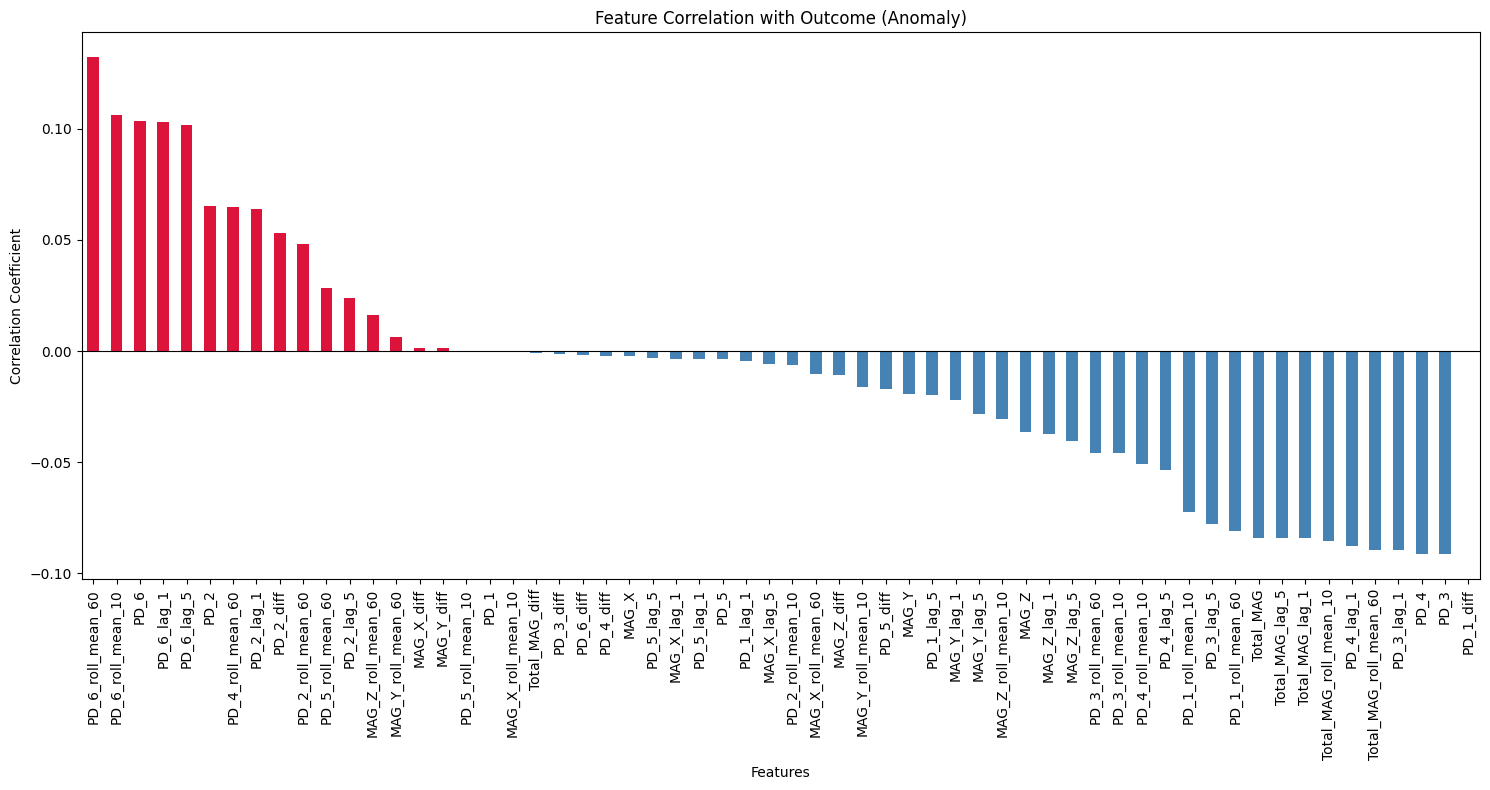

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. โหลดข้อมูลจากไฟล์ CSV
df = pd.read_csv('Data_TimeSeries.csv')

# 2. เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขเพื่อนำมาคำนวณค่าความสัมพันธ์ (Correlation)
numeric_df = df.select_dtypes(include=[np.number])

# 3. สร้าง Correlation Matrix (ตารางคำนวณความสัมพันธ์ระหว่างทุกๆ คอลัมน์)
corr_matrix = numeric_df.corr()

# 4. ดึงเฉพาะค่าความสัมพันธ์ที่มีต่อผลลัพธ์ (anomaly) 
# โดยตัดคอลัมน์ metadata ('anomaly', 'segment', 'train') ทิ้งไป และเรียงลำดับจากค่ามากไปน้อย
target_corr = corr_matrix['anomaly'].drop(['anomaly', 'segment', 'train']).sort_values(ascending=False)

# 5. ค้นหาคู่คอลัมน์ (Features) ที่มีความสัมพันธ์กันเองสูงมาก (Multicollinearity)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        
        # ข้ามการจับคู่ถ้ามีคอลัมน์ metadata ปะปนอยู่
        if col1 in ['anomaly', 'segment', 'train'] or col2 in ['anomaly', 'segment', 'train']: 
            continue
            
        val = corr_matrix.iloc[i, j]
        # เก็บเฉพาะคู่ที่มีค่า Correlation (บวกหรือลบ) มากกว่า 0.85
        if abs(val) > 0.85:
            high_corr_pairs.append((col1, col2, val))

# 6. จัดเรียงคู่ที่มีความสัมพันธ์กันเองสูงที่สุด โดยดูจากค่าสัมบูรณ์ (Absolute value)
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

# 7. พิมพ์ผลลัพธ์สำหรับการวิเคราะห์
print("Top Positive Correlations with Anomaly (ความสัมพันธ์เชิงบวกสูงสุด):")
print(target_corr.head(10))
print("\nTop Negative Correlations with Anomaly (ความสัมพันธ์เชิงลบสูงสุด):")
print(target_corr.tail(10).sort_values())

print("\nHighly Correlated Groups (คู่ตัวแปรที่สัมพันธ์กันเองสูงมาก):")
for p in high_corr_pairs[:15]:
    print(f"{p[0]} <-> {p[1]}: {p[2]:.4f}")

# 8. พล็อตคราฟแท่ง (Bar Chart) แสดงความสัมพันธ์ของทุกตัวแปรกับ Anomaly
plt.figure(figsize=(15, 8))
# ใช้สีแดง (crimson) สำหรับค่าบวก และสีน้ำเงิน (steelblue) สำหรับค่าลบ
target_corr.plot(kind='bar', color=np.where(target_corr > 0, 'crimson', 'steelblue'))
plt.title('Feature Correlation with Outcome (Anomaly)')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.axhline(0, color='black', linewidth=0.8) # วาดเส้นแกน 0
plt.tight_layout()
plt.savefig('corr_with_anomaly_thai.png')

In [2]:
import pandas as pd
import numpy as np

# Load the full time-series data
df = pd.read_csv('Data_TimeSeries.csv')
total_rows = len(df)

# Calculate exact target indices for 70/15/15 split
target_train_idx = int(total_rows * 0.70)
target_val_idx = int(total_rows * 0.85)

# Initial split by pure index
train_df = df.iloc[:target_train_idx].copy()
val_df_temp = df.iloc[target_train_idx:target_val_idx].copy()
test_df_temp = df.iloc[target_val_idx:].copy()

# Fix boundaries for TRAIN vs VAL
# If the segment at the boundary gets cut in half, move the whole segment to TRAIN
overlap_train_val = train_df.iloc[-1]['segment']
if not val_df_temp.empty and overlap_train_val in val_df_temp['segment'].values:
    # Update Train to include the whole overlapping segment
    train_df = df[df['segment'] <= overlap_train_val].copy()

# Recalculate Val start point after fixing Train boundary
val_start_idx = len(train_df)
val_df_temp2 = df.iloc[val_start_idx:target_val_idx].copy()
test_df_temp2 = df.iloc[target_val_idx:].copy()

# Fix boundaries for VAL vs TEST
# If the segment at the boundary gets cut in half, move the whole segment to VAL
if not val_df_temp2.empty and not test_df_temp2.empty:
    overlap_val_test = val_df_temp2.iloc[-1]['segment']
    if overlap_val_test in test_df_temp2['segment'].values:
        # Move the whole overlapping segment to Validation
        val_df = df[(df.index >= val_start_idx) & (df['segment'] <= overlap_val_test)].copy()
    else:
        val_df = val_df_temp2.copy()
else:
    val_df = val_df_temp2.copy()

# Everything left goes to Test
test_start_idx = val_start_idx + len(val_df)
test_df = df.iloc[test_start_idx:].copy()

# Save the final datasets
train_df.to_csv('Train_Data_70.csv', index=False)
val_df.to_csv('Val_Data_15.csv', index=False)
test_df.to_csv('Test_Data_15.csv', index=False)

# ==========================================
# Report Generation
# ==========================================
print(f"📊 DATASET SPLIT REPORT (70 / 15 / 15 by Segments)")
print("="*50)
print(f"Total rows in the whole file: {total_rows}")
print("="*50)

for name, data in [("TRAIN SET", train_df), ("VALIDATION SET", val_df), ("TEST SET", test_df)]:
    n_rows = len(data)
    n_anom = data['anomaly'].sum()
    n_nom = n_rows - n_anom
    pct_total = (n_rows / total_rows) * 100
    if n_rows > 0:
        pct_nom = (n_nom / n_rows) * 100
        pct_anom = (n_anom / n_rows) * 100
    else:
        pct_nom = pct_anom = 0
        
    print(f"\n📁 {name}")
    print(f"Total rows:        {n_rows:,} ({pct_total:.1f}% of total data)")
    print("-" * 30)
    print(f"✅ Nominal (0):    {n_nom:,} rows ({pct_nom:.1f}%)")
    print(f"❌ Anomaly (1):    {n_anom:,} rows ({pct_anom:.1f}%)")

print("\n" + "="*50)
print("Files saved successfully!")

📊 DATASET SPLIT REPORT (70 / 15 / 15 by Segments)
Total rows in the whole file: 86016

📁 TRAIN SET
Total rows:        60,255 (70.1% of total data)
------------------------------
✅ Nominal (0):    39,456 rows (65.5%)
❌ Anomaly (1):    20,799 rows (34.5%)

📁 VALIDATION SET
Total rows:        12,872 (15.0% of total data)
------------------------------
✅ Nominal (0):    11,174 rows (86.8%)
❌ Anomaly (1):    1,698 rows (13.2%)

📁 TEST SET
Total rows:        12,889 (15.0% of total data)
------------------------------
✅ Nominal (0):    9,151 rows (71.0%)
❌ Anomaly (1):    3,738 rows (29.0%)

Files saved successfully!
